Exploratory Data Analysis

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import imghdr

C:\Users\Athira K Dinesan\AppData\Local\Temp\ipykernel_3404\1958286900.py:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [3]:
DATASET_PATH = "MRL_1"
CLASSES = ["Open-Eyes", "Close-Eyes"]

In [5]:
# ultra_fast_validator.py
import cv2
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def validate_with_opencv(img_path):
    """
    More thorough check - actually tries to load the image
    Returns (path, error_type) if corrupted, None if valid
    """
    try:
        # Try to read the image
        img = cv2.imread(img_path)
        
        if img is None:
            return (img_path, "READ_FAILED")
        
        # Check if image has valid dimensions
        if img.shape[0] == 0 or img.shape[1] == 0:
            return (img_path, "ZERO_DIMENSION")
        
        # Check if file size is suspiciously small
        if os.path.getsize(img_path) < 100:  # Less than 100 bytes
            return (img_path, "TOO_SMALL")
        
        return None
        
    except Exception as e:
        return (img_path, str(e))

def deep_validate_dataset(dataset_path, classes=["Open-Eyes", "Close-Eyes"], max_workers=8):
    """
    Deep validation - actually loads each image
    Slower but catches more issues
    """
    # Collect all images
    all_images = []
    for cls in classes:
        folder = os.path.join(dataset_path, cls)
        if os.path.exists(folder):
            for img_name in os.listdir(folder):
                img_path = os.path.join(folder, img_name)
                if os.path.isfile(img_path):
                    all_images.append(img_path)
    
    print(f"🔬 Deep validation of {len(all_images)} images...")
    
    corrupted = []
    error_types = {}
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(validate_with_opencv, img): img for img in all_images}
        
        with tqdm(total=len(all_images), desc="Deep scan", unit="img") as pbar:
            for future in as_completed(futures):
                result = future.result()
                if result is not None:
                    path, error = result
                    corrupted.append(path)
                    error_types[error] = error_types.get(error, 0) + 1
                pbar.update(1)
    
    # Detailed summary
    print("\n" + "="*60)
    print("📊 DEEP VALIDATION SUMMARY")
    print("="*60)
    print(f"Total images: {len(all_images)}")
    print(f"Valid images: {len(all_images) - len(corrupted)}")
    print(f"Corrupted images: {len(corrupted)}")
    
    if error_types:
        print("\n🔴 Error breakdown:")
        for error, count in sorted(error_types.items(), key=lambda x: -x[1]):
            print(f"   {error}: {count}")
    
    return corrupted

# Usage
corrupted = deep_validate_dataset("MRL_1", max_workers=12)

🔬 Deep validation of 84898 images...


Deep scan: 100%|██████████| 84898/84898 [03:51<00:00, 366.84img/s]


📊 DEEP VALIDATION SUMMARY
Total images: 84898
Valid images: 84898
Corrupted images: 0


In [6]:
class_counts = {}

for cls in CLASSES:
    class_path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(class_path))

pd.DataFrame.from_dict(class_counts, orient="index", columns=["Count"])

,Count
Open-Eyes,42952
Close-Eyes,41946


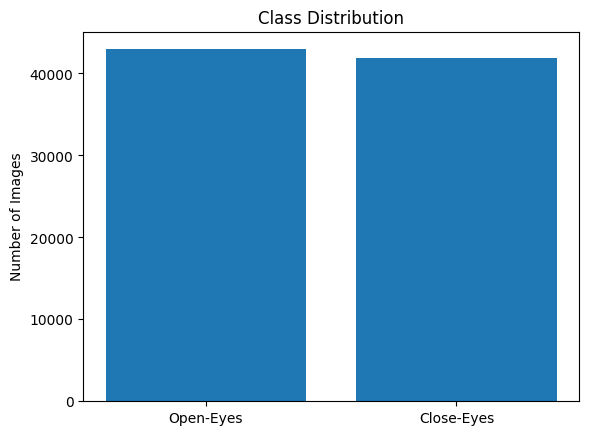

In [7]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

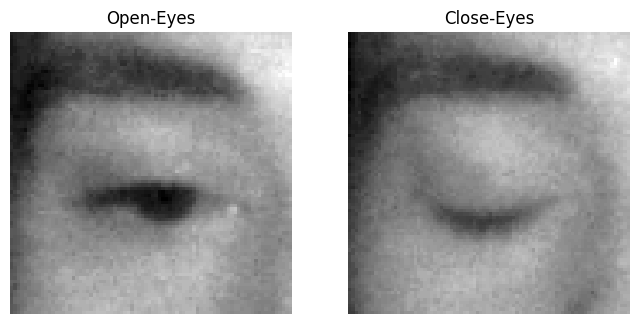

In [6]:
plt.figure(figsize=(8,4))

for i, cls in enumerate(CLASSES):
    img_name = os.listdir(os.path.join(DATASET_PATH, cls))[0]
    img_path = os.path.join(DATASET_PATH, cls, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
heights, widths = [], []

for cls in CLASSES:
    for img_name in os.listdir(os.path.join(DATASET_PATH, cls))[:4000]:
        img = cv2.imread(os.path.join(DATASET_PATH, cls, img_name), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            h, w = img.shape
            heights.append(h)
            widths.append(w)

print(f"Height range: {min(heights)} - {max(heights)}")
print(f"Width range: {min(widths)} - {max(widths)}")

Height range: 69 - 111
Width range: 69 - 111


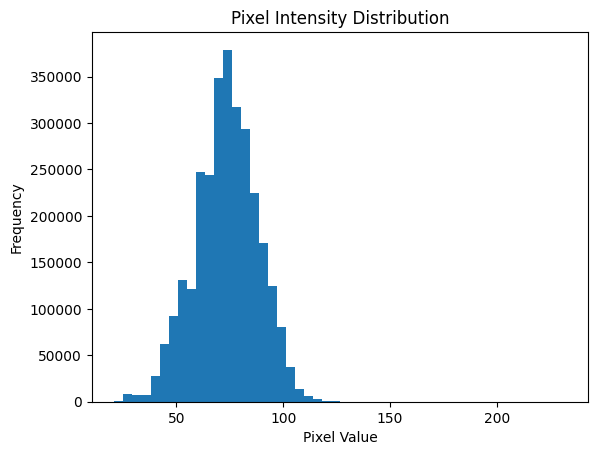

In [8]:
pixels = []

for cls in CLASSES:
    for img_name in os.listdir(os.path.join(DATASET_PATH, cls))[:200]:
        img = cv2.imread(os.path.join(DATASET_PATH, cls, img_name), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Preprocessing

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
DATASET_PATH = "MRL_1"
IMG_SIZE = 64
BATCH_SIZE = 5000 

In [3]:
# IMG_SIZE = 64
# X, y = [], []

# label_map = {"Open-Eyes": 1, "Close-Eyes": 0}
# MAX_IMAGES = 100

# for cls in ["Open-Eyes", "Close-Eyes"]:
#     folder = os.path.join("MRL_1", cls)
#     label = label_map[cls]

#     for i, img_name in enumerate(os.listdir(folder)):
#         if i >= MAX_IMAGES:
#             break

#         img_path = os.path.join(folder, img_name)
#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

#         if img is None:
#             continue

#         img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
#         img = img / 255.0

#         X.append(img)
#         y.append(label)

# X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# y = np.array(y)

# print("Loaded images:", X.shape)


In [10]:
def get_image_paths(base_path):
    data = []
    for label, folder in enumerate(["Close-Eyes", "Open-Eyes"]):
        folder_path = os.path.join(base_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".png"):
                data.append((os.path.join(folder_path, file), label))
    return data

image_label_pairs = get_image_paths(DATASET_PATH)
print("Total images found:", len(image_label_pairs))

Total images found: 84898


In [11]:
def preprocess_in_batches(data, batch_size=5000):
    X, y = [], []

    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]

        for img_path, label in batch:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            img = np.expand_dims(img, axis=-1)

            X.append(img)
            y.append(label)

        print(f"Processed {min(i + batch_size, len(data))}/{len(data)} images")

    return np.array(X), np.array(y)


In [ ]:
BATCH_SIZE = 5000 
X, y = preprocess_in_batches(image_label_pairs, BATCH_SIZE)

print("Final shape:", X.shape)
print("Labels shape:", y.shape)


In [25]:
np.save("X_mrl.npy", X)
np.save("y_mrl.npy", y)

In [13]:
X = np.load("X_mrl.npy")
y = np.load("y_mrl.npy")
print(X.shape, y.shape)

(84898, 64, 64, 1) (84898,)


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.35,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (55183, 64, 64, 1)
Val: (29715, 64, 64, 1)


Model Building 1

In [3]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

d:\Project\DDD_github\Driver-Drowsiness-Detection-\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

In [13]:
model.save("eye_state_cnn_35.keras")

Chatgpt MediaPipe CNN

In [3]:

# =============================
# Load trained CNN model
# =============================
model = tf.keras.models.load_model("eye_paper1_cnn.keras")

CLASS_NAMES = ["Closed", "Open"]

# =============================
# MediaPipe Face Landmarker
# =============================
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="face_landmarker.task"),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1
)

face_landmarker = FaceLandmarker.create_from_options(options)

# Eye landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

# =============================
# Eye cropping
# =============================
def crop_eye(frame, landmarks, eye_indices, padding=20):
    h, w, _ = frame.shape

    eye_points = [
        (int(landmarks[i].x * w), int(landmarks[i].y * h))
        for i in eye_indices
    ]

    xs = [p[0] for p in eye_points]
    ys = [p[1] for p in eye_points]

    x_min = max(min(xs) - padding, 0)
    x_max = min(max(xs) + padding, w)
    y_min = max(min(ys) - padding, 0)
    y_max = min(max(ys) + padding, h)

    eye_crop = frame[y_min:y_max, x_min:x_max]

    return eye_crop, (x_min, y_min, x_max, y_max)

# =============================
# Preprocess for CNN
# =============================
def preprocess_eye(eye_crop):
    gray = cv2.cvtColor(eye_crop, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    return normalized.reshape(1, 64, 64, 1)

# =============================
# Webcam
# =============================
cap = cv2.VideoCapture(0)
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    results = face_landmarker.detect_for_video(mp_image, frame_count)

    if results.face_landmarks:
        landmarks = results.face_landmarks[0]

        for eye_indices in [LEFT_EYE, RIGHT_EYE]:
            eye_crop, box = crop_eye(frame, landmarks, eye_indices)

            if eye_crop.size == 0:
                continue

            # CNN prediction
            eye_input = preprocess_eye(eye_crop)
            pred = model.predict(eye_input, verbose=0)[0][0]

            label = "Open" if pred > 0.5 else "Closed"
            color = (0, 255, 0) if label == "Open" else (0, 0, 255)

            # Draw bounding box & label
            cv2.rectangle(
                frame,
                (box[0], box[1]),
                (box[2], box[3]),
                color,
                2
            )

            cv2.putText(
                frame,
                f"{label} ({pred:.2f})",
                (box[0], box[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    cv2.imshow("MediaPipe + CNN Eye State Test", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


Claude MediaPipe CNN

In [ ]:
import tensorflow as tf
import cv2
import mediapipe as mp
import numpy as np
import time

# =============================
# Load trained CNN model
# =============================
model = tf.keras.models.load_model("eye_state_cnn.keras")
CLASS_NAMES = ["Closed", "Open"]

# =============================
# MediaPipe Face Landmarker
# =============================
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="face_landmarker.task"),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1
)

face_landmarker = FaceLandmarker.create_from_options(options)

# Eye landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

# =============================
# Eye cropping (optimized)
# =============================
def crop_eye(frame, landmarks, eye_indices, padding=20):
    """Optimized eye cropping"""
    h, w = frame.shape[:2]
    
    # Vectorized coordinate extraction
    eye_points = np.array([
        [int(landmarks[i].x * w), int(landmarks[i].y * h)]
        for i in eye_indices
    ])
    
    x_min = max(eye_points[:, 0].min() - padding, 0)
    x_max = min(eye_points[:, 0].max() + padding, w)
    y_min = max(eye_points[:, 1].min() - padding, 0)
    y_max = min(eye_points[:, 1].max() + padding, h)
    
    eye_crop = frame[y_min:y_max, x_min:x_max]
    
    return eye_crop, (x_min, y_min, x_max, y_max)

# =============================
# Preprocess for CNN (batch version)
# =============================
def preprocess_eyes_batch(left_crop, right_crop):
    """
    Process both eyes together for batch prediction
    2x faster than processing separately
    """
    eyes = []
    
    for eye_crop in [left_crop, right_crop]:
        if eye_crop.size == 0:
            # Return dummy if eye not detected
            eyes.append(np.zeros((64, 64, 1), dtype=np.float32))
        else:
            gray = cv2.cvtColor(eye_crop, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (64, 64))
            normalized = resized / 255.0
            eyes.append(normalized.reshape(64, 64, 1))
    
    # Stack into batch: shape (2, 64, 64, 1)
    return np.array(eyes, dtype=np.float32)

# =============================
# FPS Counter
# =============================
class FPSCounter:
    def __init__(self):
        self.prev_time = time.time()
        self.fps = 0
    
    def update(self):
        current_time = time.time()
        self.fps = 1 / (current_time - self.prev_time)
        self.prev_time = current_time
        return self.fps

# =============================
# Main Loop (OPTIMIZED)
# =============================
cap = cv2.VideoCapture(0)
frame_count = 0
fps_counter = FPSCounter()

# Reduce webcam resolution for faster processing (optional)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    results = face_landmarker.detect_for_video(mp_image, frame_count)

    if results.face_landmarks:
        landmarks = results.face_landmarks[0]

        # Crop both eyes
        left_crop, left_box = crop_eye(frame, landmarks, LEFT_EYE)
        right_crop, right_box = crop_eye(frame, landmarks, RIGHT_EYE)

        # 🚀 BATCH PREDICTION (2x faster!)
        if left_crop.size > 0 and right_crop.size > 0:
            eyes_batch = preprocess_eyes_batch(left_crop, right_crop)
            
            # Single prediction for both eyes
            predictions = model.predict(eyes_batch, verbose=0)
            
            left_pred = predictions[0][0]
            right_pred = predictions[1][0]
            
            # Draw results for both eyes
            for pred, box in [(left_pred, left_box), (right_pred, right_box)]:
                label = "Open" if pred > 0.5 else "Closed"
                color = (0, 255, 0) if label == "Open" else (0, 0, 255)
                
                cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), color, 2)
                cv2.putText(
                    frame,
                    f"{label} ({pred:.2f})",
                    (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2
                )

    # Display FPS
    fps = fps_counter.update()
    cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    cv2.imshow("Optimized Eye State Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

d:\Project\Driver Drowsiness Detection (YOLO)\.venv11\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model Building 2

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, BatchNormalization, 
    GlobalAveragePooling2D, Dense, Dropout, Input
)

In [29]:
model = Sequential([
        Input(shape=(64, 64, 1)),
        
        # Block 1: Initial feature extraction
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same', strides=2),
        BatchNormalization(),
        Dropout(0.2),
        
        # Block 2: Depthwise separable (MobileNet-inspired, but smaller)
        DepthwiseConv2D((3,3), activation='relu', padding='same'),
        Conv2D(64, (1,1), activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same', strides=2),
        BatchNormalization(),
        Dropout(0.2),
        
        # Block 3: Deep features
        DepthwiseConv2D((3,3), activation='relu', padding='same'),
        Conv2D(128, (1,1), activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same', strides=2),
        BatchNormalization(),
        Dropout(0.3),
        
        # Classification head
        GlobalAveragePooling2D(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy','AUC']
)

model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32 
)

In [32]:
model.save("eye_claude_cnn.keras")

Model Building 3

In [ ]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy','AUC']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32 
)

In [10]:
model.save("eye_paper1_cnn.keras")

Combination of CNN and EAR

In [7]:
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
from collections import deque   # NEW

# =============================
# Load trained CNN model
# =============================
model = tf.keras.models.load_model("eye_paper1_cnn.keras")
CLASS_NAMES = ["Closed", "Open"]

# =============================
# MediaPipe Face Landmarker
# =============================
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="face_landmarker.task"),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1
)

face_landmarker = FaceLandmarker.create_from_options(options)

# Eye landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

# =============================
# EAR calculation  (NEW)
# =============================
def compute_ear(landmarks, eye_indices, w, h):
    pts = np.array([
        [landmarks[i].x * w, landmarks[i].y * h]
        for i in eye_indices
    ])

    # EAR formula
    A = np.linalg.norm(pts[1] - pts[5])
    B = np.linalg.norm(pts[2] - pts[4])
    C = np.linalg.norm(pts[0] - pts[3])

    ear = (A + B) / (2.0 * C)
    return ear

EAR_THRESHOLD = 0.22   # tune between 0.18–0.25

# =============================
# Eye cropping
# =============================
def crop_eye(frame, landmarks, eye_indices, padding=20):
    h, w, _ = frame.shape

    eye_points = [
        (int(landmarks[i].x * w), int(landmarks[i].y * h))
        for i in eye_indices
    ]

    xs = [p[0] for p in eye_points]
    ys = [p[1] for p in eye_points]

    x_min = max(min(xs) - padding, 0)
    x_max = min(max(xs) + padding, w)
    y_min = max(min(ys) - padding, 0)
    y_max = min(max(ys) + padding, h)

    eye_crop = frame[y_min:y_max, x_min:x_max]

    return eye_crop, (x_min, y_min, x_max, y_max)

# =============================
# Preprocess for CNN
# =============================
def preprocess_eye(eye_crop):
    gray = cv2.cvtColor(eye_crop, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    return normalized.reshape(1, 64, 64, 1)

# =============================
# Temporal buffer for drowsiness (NEW)
# =============================
EYE_BUFFER = deque(maxlen=15)   # ~0.5 sec history

# =============================
# Webcam
# =============================
cap = cv2.VideoCapture(0)
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    results = face_landmarker.detect_for_video(mp_image, frame_count)

    if results.face_landmarks:
        landmarks = results.face_landmarks[0]
        h, w, _ = frame.shape

        eye_states = []   # NEW

        for eye_indices in [LEFT_EYE, RIGHT_EYE]:

            # ===== EAR =====
            ear = compute_ear(landmarks, eye_indices, w, h)

            # ===== CNN =====
            eye_crop, box = crop_eye(frame, landmarks, eye_indices)
            if eye_crop.size == 0:
                continue

            eye_input = preprocess_eye(eye_crop)
            pred = model.predict(eye_input, verbose=0)[0][0]
            cnn_label = "Open" if pred > 0.5 else "Closed"

            # ===== FUSION RULE =====
            if ear < EAR_THRESHOLD:
                final_label = "Closed"   # EAR override
            else:
                final_label = cnn_label

            eye_states.append(final_label)

            color = (0, 255, 0) if final_label == "Open" else (0, 0, 255)

            cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), color, 2)
            cv2.putText(
                frame,
                f"{final_label} EAR:{ear:.2f}",
                (box[0], box[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

        # ===== DROWSINESS LOGIC =====
        if "Closed" in eye_states:
            EYE_BUFFER.append(1)
        else:
            EYE_BUFFER.append(0)

        if sum(EYE_BUFFER) > 10:   # eyes closed most frames
            cv2.putText(
                frame,
                "DROWSINESS ALERT!",
                (50, 80),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (0, 0, 255),
                3
            )

    cv2.imshow("EAR + CNN Fusion", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()